# Simplified Vision Transformer (PyTorch)

ViT를 이용한 SVHN(총 10개의 클래스) 이미지 분류  

### GPU 필요하므로 Colab에서 실행

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

In [2]:
num_classes = 10

# SVHN 다운로드 (torchvision)
train_dataset_raw = torchvision.datasets.SVHN(root='./data', split='train', download=True)
test_dataset_raw = torchvision.datasets.SVHN(root='./data', split='test', download=True)

# SVHN의 .data는 (N, 3, 32, 32) 형태이므로 (N, 32, 32, 3)으로 변환
X_train = np.transpose(np.array(train_dataset_raw.data), (0, 2, 3, 1))  # (73257, 32, 32, 3)
y_train = np.array(train_dataset_raw.labels)                             # (73257,)
X_test = np.transpose(np.array(test_dataset_raw.data), (0, 2, 3, 1))    # (26032, 32, 32, 3)
y_test = np.array(test_dataset_raw.labels)                               # (26032,)

X_train.shape, y_train.shape, X_test.shape, y_test.shape

100%|██████████| 182M/182M [01:00<00:00, 3.03MB/s]
100%|██████████| 64.3M/64.3M [00:21<00:00, 2.96MB/s]


((73257, 32, 32, 3), (73257,), (26032, 32, 32, 3), (26032,))

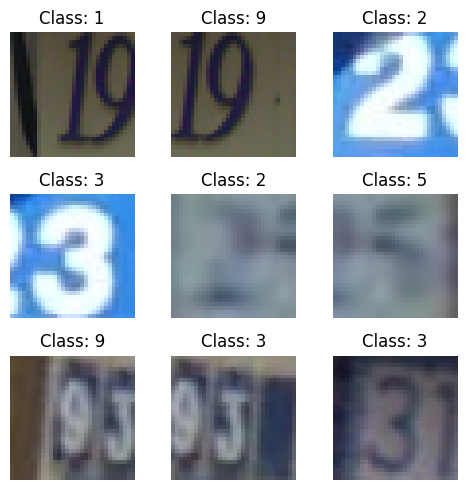

In [3]:
plt.figure(figsize=(5, 5))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(X_train[i])
    plt.title(f"Class: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()

SVHN 데이터셋은 Google Street View에서 촬영한 집 번호판의 숫자 이미지로, 크기가 32x32입니다. Vision Transformer 모델을 적용하기 위해 32x32 이미지를 224x224 크기로 변경하여 패치로 분할합니다. 이렇게 하면 모델이 더 큰 패치에서 특징을 추출하고 이미지 내의 다양한 정보를 고려할 수 있게 됩니다.

In [4]:
# 배치 크기 (한 번에 처리할 이미지 수)
batch_size = 256

# 이미지 크기 (가로와 세로 크기가 동일한 이미지)
image_size = 224

# 이미지를 나눌 패치(patch) 크기
patch_size = 32

# 이미지를 패치로 나눌 때 생성되는 패치 개수
num_patches = (image_size // patch_size) ** 2

# D (임베딩 차원 및 어텐션 헤드 개수 설정)
projection_dim = 64
num_heads = 4

# 트랜스포머 블록 내부의 레이어 유닛 개수 설정
transformer_units = [
    projection_dim * 2,
    projection_dim
]

# 트랜스포머 블록의 층 수 설정
transformer_layers = 12

# MLP 헤드 내부의 레이어 유닛 개수 설정
mlp_head_units = [2048, 1024]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 디바이스: {device}")

사용 디바이스: cuda


In [5]:
# 학습 데이터의 평균/표준편차 계산 (정규화용)
mean = X_train.astype(np.float32).mean(axis=(0, 1, 2)) / 255.0
std = X_train.astype(np.float32).std(axis=(0, 1, 2)) / 255.0

# 학습용 데이터 증강 + 전처리
train_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(degrees=7),
    transforms.RandomResizedCrop(image_size, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

# 테스트용 전처리 (증강 없음)
test_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

# torchvision 데이터셋 생성 (transform 적용)
train_dataset = torchvision.datasets.SVHN(root='./data', split='train', transform=train_transform)
test_dataset = torchvision.datasets.SVHN(root='./data', split='test', transform=test_transform)

# DataLoader 생성
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"학습: {len(train_dataset)}, 테스트: {len(test_dataset)}")

학습: 73257, 테스트: 26032


In [6]:
# MLP (다층 퍼셉트론) 모듈 정의
class MLP(nn.Module):
    def __init__(self, in_features, hidden_units, dropout_rate):
        super().__init__()
        layers = []
        prev_units = in_features
        for units in hidden_units:
            layers.append(nn.Linear(prev_units, units))
            layers.append(nn.GELU())
            layers.append(nn.Dropout(dropout_rate))
            prev_units = units
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

### Patch 추출

PyTorch에서는 `torch.nn.functional.unfold` 또는 직접 reshape/view를 사용하여 이미지를 패치로 분할합니다.

입력 이미지 `(B, C, H, W)`를 `(B, num_patches, patch_dim)` 형태로 변환합니다.

- `patch_dim = patch_size * patch_size * C` (패치 하나의 픽셀 수 x 채널 수)

In [7]:
class Patches(nn.Module):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size

    def forward(self, images):
        # images: (B, C, H, W)
        B, C, H, W = images.shape
        p = self.patch_size

        # (B, C, H//p, p, W//p, p) -> (B, H//p * W//p, p*p*C)
        patches = images.unfold(2, p, p).unfold(3, p, p)  # (B, C, H//p, W//p, p, p)
        patches = patches.contiguous().view(B, C, -1, p, p)  # (B, C, num_patches, p, p)
        patches = patches.permute(0, 2, 3, 4, 1)  # (B, num_patches, p, p, C)
        patches = patches.contiguous().view(B, -1, p * p * C)  # (B, num_patches, patch_dim)
        return patches

### 학습 데이터 시각화
본래의 32X32 image를 224X224 로 resize 하였으므로 사진이 흐릿하게 보일 수 있음.

Image 크기: 224 X 224
Patch 크기: 32 X 32
이미지당 patch 수: 49
patch당 element 갯수: 3072
Shape of patch: torch.Size([1, 49, 3072])


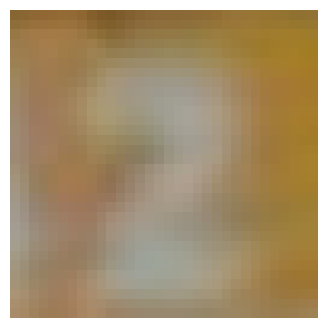

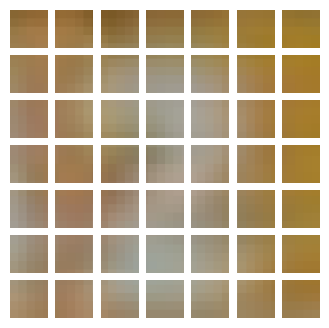

In [8]:
plt.figure(figsize=(4, 4))

# 학습 데이터셋에서 랜덤하게 이미지 하나를 선택
image = X_train[np.random.choice(range(X_train.shape[0]))]

# 선택된 이미지 시각화
plt.imshow(image.astype('uint8'))
plt.axis('off')

# 이미지 크기 조절 및 패치 추출
resized = torch.nn.functional.interpolate(
    torch.from_numpy(image).permute(2, 0, 1).unsqueeze(0).float(),
    size=(image_size, image_size)
)  # (1, 3, 224, 224)

patches = Patches(patch_size)(resized)  # (1, num_patches, patch_dim)

# 이미지와 패치 정보 출력
print(f'Image 크기: {image_size} X {image_size}')
print(f'Patch 크기: {patch_size} X {patch_size}')
print(f'이미지당 patch 수: {patches.shape[1]}')
print(f'patch당 element 갯수: {patches.shape[-1]}')
print(f'Shape of patch: {patches.shape}')

# 패치들을 시각화
n = int(np.sqrt(patches.shape[1]))
plt.figure(figsize=(4, 4))
for i in range(patches.shape[1]):
    ax = plt.subplot(n, n, i + 1)
    patch_img = patches[0, i].view(patch_size, patch_size, 3).numpy().astype('uint8')
    plt.imshow(patch_img)
    plt.axis('off')

### PatchEncoder 정의
- Vision Transformer (ViT) 모델의 핵심 구성 요소 중 하나인 PatchEncoder 클래스를 정의  
- 이 클래스는 패치를 인코딩하고 위치 정보를 임베딩

In [9]:
class PatchEncoder(nn.Module):
    def __init__(self, num_patches, patch_dim, projection_dim):
        super().__init__()
        self.num_patches = num_patches

        # 패치를 projection_dim 차원으로 투영
        self.projection = nn.Linear(patch_dim, projection_dim)

        # 위치 임베딩
        self.position_embedding = nn.Embedding(num_patches, projection_dim)

    def forward(self, patch):
        # position: [0, 1, 2, ..., num_patches-1]
        position = torch.arange(0, self.num_patches, device=patch.device)

        # 패치를 투영하고 위치 임베딩을 더해 반환
        encoded = self.projection(patch) + self.position_embedding(position)
        return encoded

<img src="https://viso.ai/wp-content/uploads/2021/09/vision-transformer-vit.png" width=700 />

In [10]:
class VisionTransformer(nn.Module):
    def __init__(self, image_size, patch_size, num_classes, projection_dim,
                 num_heads, transformer_layers, transformer_units, mlp_head_units):
        super().__init__()

        self.num_patches = (image_size // patch_size) ** 2
        self.patch_dim = patch_size * patch_size * 3

        self.patches = Patches(patch_size)
        self.patch_encoder = PatchEncoder(self.num_patches, self.patch_dim, projection_dim)

        # Transformer 블록들
        self.transformer_blocks = nn.ModuleList()
        for _ in range(transformer_layers):
            self.transformer_blocks.append(nn.ModuleDict({
                'norm1': nn.LayerNorm(projection_dim, eps=1e-6),
                'attn': nn.MultiheadAttention(
                    embed_dim=projection_dim, num_heads=num_heads,
                    dropout=0.1, batch_first=True
                ),
                'norm2': nn.LayerNorm(projection_dim, eps=1e-6),
                'mlp': MLP(projection_dim, transformer_units, dropout_rate=0.1),
            }))

        # 최종 분류 헤드
        self.final_norm = nn.LayerNorm(projection_dim, eps=1e-6)
        self.dropout = nn.Dropout(0.5)
        self.mlp_head = MLP(self.num_patches * projection_dim, mlp_head_units, dropout_rate=0.5)
        self.classifier = nn.Linear(mlp_head_units[-1], num_classes)

    def forward(self, x):
        # 패치 추출 및 인코딩
        patches = self.patches(x)
        encoded_patches = self.patch_encoder(patches)

        # Transformer 블록 반복
        for block in self.transformer_blocks:
            x1 = block['norm1'](encoded_patches)
            attention_output, _ = block['attn'](x1, x1, x1)
            x2 = attention_output + encoded_patches
            x3 = block['norm2'](x2)
            x3 = block['mlp'](x3)
            encoded_patches = x3 + x2

        # 분류 헤드
        representation = self.final_norm(encoded_patches)
        representation = representation.flatten(start_dim=1)
        representation = self.dropout(representation)
        features = self.mlp_head(representation)
        logits = self.classifier(features)
        return logits

In [11]:
model = VisionTransformer(
    image_size=image_size,
    patch_size=patch_size,
    num_classes=num_classes,
    projection_dim=projection_dim,
    num_heads=num_heads,
    transformer_layers=transformer_layers,
    transformer_units=transformer_units,
    mlp_head_units=mlp_head_units,
).to(device)

# 파라미터 수 출력
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")
print(model)

Total params: 9,134,602
Trainable params: 9,134,602
VisionTransformer(
  (patches): Patches()
  (patch_encoder): PatchEncoder(
    (projection): Linear(in_features=3072, out_features=64, bias=True)
    (position_embedding): Embedding(49, 64)
  )
  (transformer_blocks): ModuleList(
    (0-11): 12 x ModuleDict(
      (norm1): LayerNorm((64,), eps=1e-06, elementwise_affine=True)
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
      )
      (norm2): LayerNorm((64,), eps=1e-06, elementwise_affine=True)
      (mlp): MLP(
        (net): Sequential(
          (0): Linear(in_features=64, out_features=128, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_features=128, out_features=64, bias=True)
          (4): GELU(approximate='none')
          (5): Dropout(p=0.1, inplace=False)
        )
      )
    )
  )
  (final_norm): LayerNorm((64,), eps=1

In [12]:
# 더미 입력으로 forward pass 테스트
dummy_input = torch.randn(1, 3, image_size, image_size).to(device)
dummy_output = model(dummy_input)
print(f"입력 shape: {dummy_input.shape}")
print(f"출력 shape: {dummy_output.shape}")

입력 shape: torch.Size([1, 3, 224, 224])
출력 shape: torch.Size([1, 10])


### model Train

In [13]:
import time

num_epochs = 5
learning_rate = 0.001

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()

history = {'loss': [], 'accuracy': [], 'test_loss': [], 'test_accuracy': []}

start_time = time.time()

for epoch in range(num_epochs):
    # === 학습 ===
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
    for images, labels in progress_bar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

        progress_bar.set_postfix({
            'loss': f'{running_loss/total:.4f}',
            'acc': f'{correct/total:.4f}'
        })

    train_loss = running_loss / total
    train_acc = correct / total

    # === 테스트 ===
    model.eval()
    test_loss = 0.0
    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            test_correct += predicted.eq(labels).sum().item()
            test_total += labels.size(0)

    test_loss /= test_total
    test_acc = test_correct / test_total

    history['loss'].append(train_loss)
    history['accuracy'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_accuracy'].append(test_acc)

    print(f"Epoch {epoch+1}/{num_epochs} - "
          f"loss: {train_loss:.4f} - accuracy: {train_acc:.4f} - "
          f"test_loss: {test_loss:.4f} - test_accuracy: {test_acc:.4f}")

elapsed = time.time() - start_time
minutes, seconds = divmod(elapsed, 60)
print(f"\n총 학습 시간: {int(minutes)}분 {seconds:.1f}초")

Epoch 1/5:   0%|          | 0/287 [00:00<?, ?it/s]

Epoch 1/5 - loss: 1.6698 - accuracy: 0.4254 - test_loss: 1.0507 - test_accuracy: 0.6589


Epoch 2/5:   0%|          | 0/287 [00:00<?, ?it/s]

Epoch 2/5 - loss: 1.0894 - accuracy: 0.6451 - test_loss: 0.8477 - test_accuracy: 0.7317


Epoch 3/5:   0%|          | 0/287 [00:00<?, ?it/s]

Epoch 3/5 - loss: 0.9152 - accuracy: 0.7042 - test_loss: 0.7409 - test_accuracy: 0.7734


Epoch 4/5:   0%|          | 0/287 [00:00<?, ?it/s]

Epoch 4/5 - loss: 0.8166 - accuracy: 0.7376 - test_loss: 0.6366 - test_accuracy: 0.8066


Epoch 5/5:   0%|          | 0/287 [00:00<?, ?it/s]

Epoch 5/5 - loss: 0.7431 - accuracy: 0.7661 - test_loss: 0.5914 - test_accuracy: 0.8131

총 학습 시간: 25분 44.9초


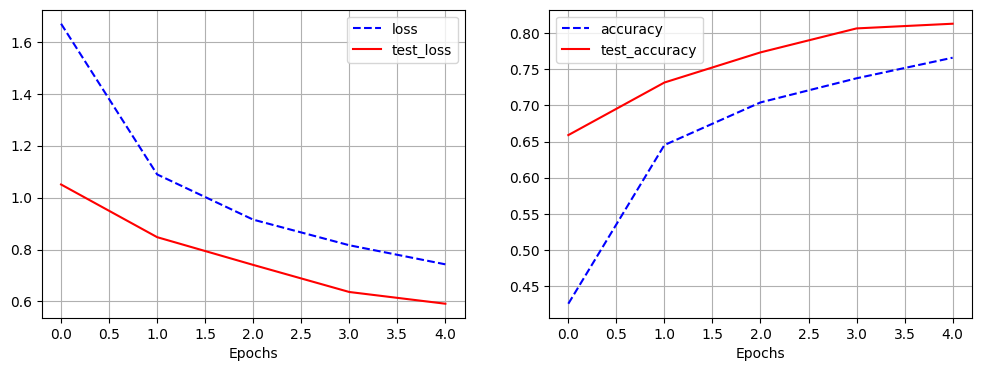

In [14]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['loss'], 'b--', label='loss')
plt.plot(history['test_loss'], 'r', label='test_loss')
plt.xlabel('Epochs')
plt.grid()
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], 'b--', label='accuracy')
plt.plot(history['test_accuracy'], 'r', label='test_accuracy')
plt.xlabel('Epochs')
plt.grid()
plt.legend()

### 테스트 데이터로 예측

In [15]:
# 테스트 이미지 하나를 전처리하여 모델에 입력
img_pil = Image.fromarray(X_test[0])
img = test_transform(img_pil).unsqueeze(0).to(device)  # (1, 3, 224, 224)
img.shape

torch.Size([1, 3, 224, 224])

In [16]:
model.eval()
with torch.no_grad():
    predictions = model(img)  # (1, 10)
predictions.shape

torch.Size([1, 10])

In [19]:
# 테스트 데이터 전체에 대한 accuracy 계산
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

print(f"Test Accuracy: {correct / total:.4f} ({correct}/{total})")

Test Accuracy: 0.8131 (21167/26032)
